# rejectkit — walkthrough / 사용 예제 / 使い方ノートブック

**[한국어]** 샘플 데이터로 `rejectkit`의 모든 핵심 함수를 하나씩 실행해 본다. 위에서 아래로 그냥 실행하면 된다.

**[English]** Runs every core piece of `rejectkit` on small sample data, top to bottom.

**[日本語]** サンプルデータで `rejectkit` の主要関数を上から順に実行する。

In [1]:
import sys, pathlib
for _p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
    if (_p / 'src' / 'rejectkit').exists():
        sys.path.insert(0, str(_p / 'src')); break
%matplotlib inline
import numpy as np, pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import rejectkit as rk
from rejectkit import (SimpleAugmentation, FuzzyAugmentation, Parcelling, Reclassification,
                       Extrapolation, Reweighting, SelfLearning, HeckmanClassifier,
                       RejectInferenceClassifier, get_inferencer, MaskedRejectBenchmark, plotting)
from rejectkit.datasets import make_credit_data, make_accept_reject
from rejectkit.diagnostics import auc, gini, ks_statistic, psi, feature_drift, swap_set
pd.set_option('display.width', 130); pd.set_option('display.max_columns', 20)
print('rejectkit', rk.__version__)

rejectkit 0.3.0


## 1. Sample data / 샘플 데이터 / サンプルデータ

**[한국어]** `make_credit_data`는 정답이 다 있는 데이터, `make_accept_reject`는 승인/거절로 나눈 데이터를 만든다. 승인자 부도율과 거절자(숨은) 실제 부도율의 차이에서 편향이 한눈에 보인다.

**[English]** `make_credit_data` gives a fully labelled set; `make_accept_reject` splits into accepts/rejects. The gap between the accept bad rate and the rejects' hidden true bad rate shows the bias at a glance.

**[日本語]** `make_credit_data` は全ラベル付きデータ、`make_accept_reject` は承認/否認に分けたデータを作る。承認者の延滞率と否認者（隠れた）真の延滞率の差にバイアスが表れる。

In [2]:
X, y = make_credit_data(n_samples=2000, n_features=6, bad_rate=0.3, random_state=0)
print('X', X.shape, '| overall bad rate', round(y.mean(), 3))
display(X.head(3).round(3))
X_accept, y_accept, X_reject, y_reject_true = make_accept_reject(
    n_samples=2000, n_features=6, accept_rate=0.6, random_state=0)
print(f'accepts={len(X_accept)} (bad rate {y_accept.mean():.3f})  '
      f'rejects={len(X_reject)} (hidden true bad rate {y_reject_true.mean():.3f})')
display(X_accept.head(3).round(3))

X (2000, 6) | overall bad rate 0.291


,x1,x2,x3,x4,x5,x6
0,0.126,-0.132,0.640,0.105,-0.536,0.362
1,1.304,0.947,-0.704,-1.265,-0.623,0.041
2,-2.325,-0.219,-1.246,-0.732,-0.544,-0.316


accepts=1200 (bad rate 0.048)  rejects=800 (hidden true bad rate 0.655)


,x1,x2,x3,x4,x5,x6
0,0.126,-0.132,0.640,0.105,-0.536,0.362
1,1.304,0.947,-0.704,-1.265,-0.623,0.041
2,-2.325,-0.219,-1.246,-0.732,-0.544,-0.316


## 2. Methods — `fit_resample()` / 기법별 출력 / 各手法の出力

**[한국어]** 각 기법이 거절자를 어떻게 채우는지 비교한다. fuzzy/parcelling/extrapolation은 거절자를 good/bad 두 줄(소수 가중치)로, reweighting은 라벨 없이 가중치만, simple/reclassification/selflearning은 가중치 1로 넣는다.

**[English]** Compare how each method folds rejects in: fuzzy/parcelling/extrapolation add two weighted rows per reject, reweighting only reweights accepts (no labels), simple/reclassification/selflearning add unit-weight rows.

**[日本語]** 各手法が否認者をどう取り込むか比較する。fuzzy/parcelling/extrapolation は否認者を good/bad の2行（小数の重み）に、reweighting はラベル無しで重みだけ、simple/reclassification/selflearning は重み1で加える。

In [3]:
methods = {'SimpleAugmentation': SimpleAugmentation(), 'FuzzyAugmentation': FuzzyAugmentation(),
           'Parcelling(uplift=1.3)': Parcelling(uplift=1.3), 'Reclassification': Reclassification(),
           'Extrapolation': Extrapolation(n_neighbors=15), 'Reweighting': Reweighting(),
           'SelfLearning': SelfLearning()}
rows = []
for name, m in methods.items():
    Xn, yn, w = m.fit_resample(X_accept, y_accept, X_reject)
    rows.append({'method': name, 'rows': len(Xn), 'extra_over_accepts': len(Xn)-len(X_accept),
                 'w_min': round(float(w.min()),2), 'w_mean': round(float(w.mean()),2),
                 'w_max': round(float(w.max()),2)})
display(pd.DataFrame(rows).set_index('method'))
Xf, yf, wf = FuzzyAugmentation().fit_resample(X_accept, y_accept, X_reject)
na, nr = len(X_accept), len(X_reject)
print(f'FuzzyAugmentation, reject #0 -> two rows: label={yf[na]} w={wf[na]:.3f} | '
      f'label={yf[na+nr]} w={wf[na+nr]:.3f}  (sum={wf[na]+wf[na+nr]:.3f})')

,rows,extra_over_accepts,w_min,w_mean,w_max
method,,,,,
SimpleAugmentation,2000,800,1.0,1.00,1.00
FuzzyAugmentation,2800,1600,0.0,0.71,1.00
Parcelling(uplift=1.3),2800,1600,0.0,0.71,1.00
Reclassification,2000,800,1.0,1.00,1.00
Extrapolation,2800,1600,0.0,0.71,1.00
Reweighting,1200,0,0.6,1.00,17.36
SelfLearning,1990,790,1.0,1.00,1.00


FuzzyAugmentation, reject #0 -> two rows: label=1 w=0.002 | label=0 w=0.998  (sum=1.000)


## 3. `RejectInferenceClassifier` & `get_inferencer`

**[한국어]** 원클릭 래퍼. 방법을 고르면 거절자 채우기→학습→예측을 한 번에. 내부 모델은 무엇이든 교체 가능.

**[English]** The one-click wrapper: pick a method, it fills rejects, trains, and predicts. Swap the inner model freely.

**[日本語]** ワンクリックのラッパー。手法を選べば否認者補完→学習→予測まで一括。内部モデルは自由に差し替え可能。

In [4]:
print("get_inferencer('fuzzy') ->", type(get_inferencer('fuzzy')).__name__)
clf = RejectInferenceClassifier(estimator=LogisticRegression(max_iter=1000),
                                method='parcelling', method_params={'uplift': 1.2}
                                ).fit(X_accept, y_accept, X_reject)
proba = clf.predict_proba(X_reject)
print('predict_proba shape', proba.shape, '(col 1 = P(bad))')
display(pd.DataFrame(proba[:5].round(3), columns=['P(good)', 'P(bad)']))
print('predict[:12]:', clf.predict(X_reject)[:12])

get_inferencer('fuzzy') -> FuzzyAugmentation
predict_proba shape (800, 2) (col 1 = P(bad))


,P(good),P(bad)
0,0.998,0.002
1,0.757,0.243
2,0.641,0.359
3,0.826,0.174
4,0.998,0.002


predict[:12]: [0 0 0 0 0 0 0 0 0 0 0 0]


## 4. `HeckmanClassifier`

**[한국어]** 통제함수(역 Mills 비)를 피처로 추가하는 독립 분류기. 같은 `fit/predict_proba` 형식.

**[English]** Standalone classifier that adds the inverse Mills ratio as a feature. Same `fit/predict_proba` shape.

**[日本語]** 逆ミルズ比を特徴量として加える独立分類器。`fit/predict_proba` の形式は同じ。

In [5]:
heck = HeckmanClassifier().fit(X_accept, y_accept, X_reject)
display(pd.DataFrame(heck.predict_proba(X_reject)[:5].round(3), columns=['P(good)', 'P(bad)']))

,P(good),P(bad)
0,0.998,0.002
1,0.811,0.189
2,0.670,0.330
3,0.860,0.140
4,0.998,0.002


## 5. `MaskedRejectBenchmark` — does it help? / 도움이 되나? / 役立つか?

**[한국어]** `auc_recovery`: 0=naive와 동급, 1=oracle만큼 회복, 음수=악화. 이 MNAR 예시에선 parcelling만 약간 +.

**[English]** `auc_recovery`: 0 = tied with naive, 1 = recovers the oracle, negative = worse. In this MNAR example only parcelling is slightly positive.

**[日本語]** `auc_recovery`：0=naive と同等、1=oracle まで回復、負=悪化。この MNAR 例では parcelling だけがわずかに +。

In [6]:
bench = MaskedRejectBenchmark(selection='mnar', accept_rate=0.6, random_state=0)
results = bench.compare(['simple','fuzzy','parcelling','reweighting',
                         'extrapolation','selflearning','heckman'], X, y)
print('attrs:', {k: results.attrs[k] for k in ('n_accept','n_reject','n_test','selection')})
display(results.round(4))

attrs: {'n_accept': 840, 'n_reject': 560, 'n_test': 600, 'selection': 'mnar'}


,auc,ks,gini,auc_recovery
oracle,0.8083,0.4760,0.6165,1.0000
naive,0.7702,0.4124,0.5405,0.0000
simple,0.7501,0.4131,0.5002,-0.5293
fuzzy,0.7702,0.4124,0.5405,-0.0000
parcelling,0.7753,0.4134,0.5507,0.1340
reweighting,0.7562,0.4017,0.5123,-0.3702
extrapolation,0.7527,0.4030,0.5053,-0.4625
selflearning,0.7346,0.3919,0.4692,-0.9378
heckman,0.7686,0.4101,0.5373,-0.0424


## 6. Diagnostics / 진단 / 診断

**[한국어]** `auc/gini/ks/psi` 지표, `feature_drift`(승인 vs 거절 변수별 PSI), `swap_set`(스코어카드 교체 영향).

**[English]** `auc/gini/ks/psi` metrics, `feature_drift` (per-feature accept-vs-reject PSI), `swap_set` (impact of changing scorecards).

**[日本語]** `auc/gini/ks/psi` 指標、`feature_drift`（承認 vs 否認の特徴量別 PSI）、`swap_set`（スコアカード変更の影響）。

In [7]:
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)
score = LogisticRegression(max_iter=1000).fit(Xtr, ytr).predict_proba(Xte)[:, 1]
print(f'auc={auc(yte, score):.4f}  gini={gini(yte, score):.4f}  ks={ks_statistic(yte, score):.4f}')
print('feature_drift (accept vs reject PSI):')
display(feature_drift(X_accept, X_reject).round(3).to_frame())
m_new = RandomForestClassifier(n_estimators=50, random_state=0).fit(Xtr, ytr)
s_new = m_new.predict_proba(Xte)[:, 1]
print('swap_set (reference=LR vs challenger=RF, accept safest 60%):')
display(swap_set(yte, score, s_new, np.quantile(score, 0.6), np.quantile(s_new, 0.6)).round(3))

auc=0.8083  gini=0.6165  ks=0.4760
feature_drift (accept vs reject PSI):


,psi
x2,0.622
x5,0.233
x6,0.148
x4,0.125
x3,0.028
x1,0.021


swap_set (reference=LR vs challenger=RF, accept safest 60%):


,n,bad_rate
kept_accept,335.0,0.131
swap_out,25.0,0.080
swap_in,39.0,0.436
kept_reject,201.0,0.557


## 7. Plotting / 시각화 / 可視化

**[한국어]** 벤치마크 막대, 승인 vs 거절 점수 분포, KS 곡선.

**[English]** Benchmark bars, accept-vs-reject score distributions, KS curve.

**[日本語]** ベンチマーク棒グラフ、承認 vs 否認のスコア分布、KS 曲線。

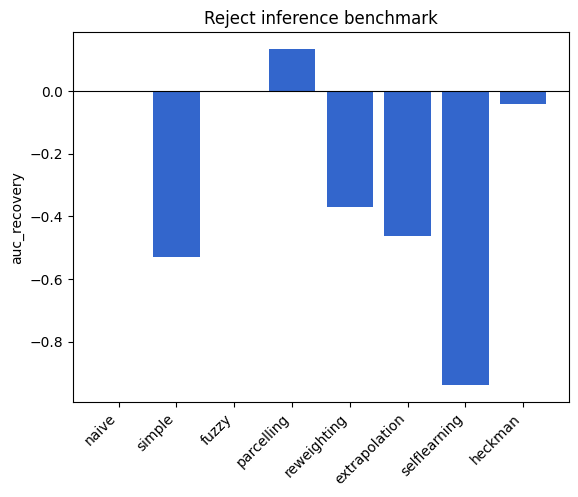

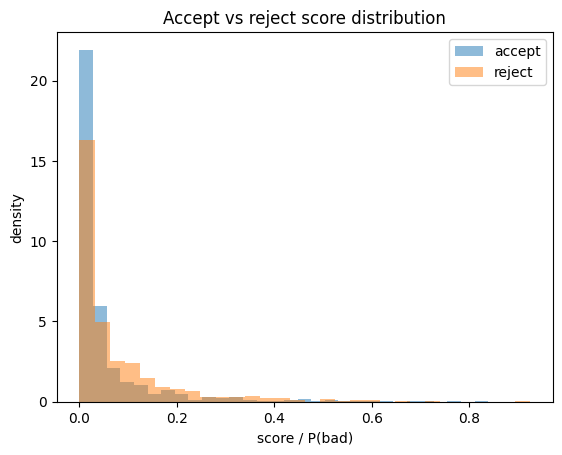

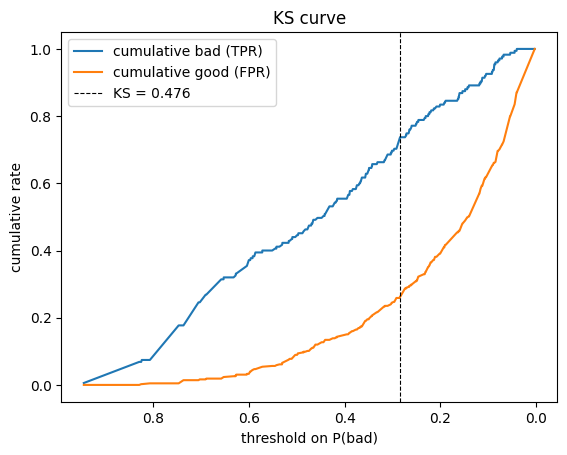

In [8]:
plotting.plot_benchmark(results)
plotting.plot_score_distributions(clf.predict_proba(X_accept)[:, 1], clf.predict_proba(X_reject)[:, 1])
plotting.plot_ks(yte, score)
None

## Takeaway / 결론 / まとめ

**[한국어]** reject inference는 만능이 아니다. 항상 `MaskedRejectBenchmark`로 네 데이터에서 먼저 확인하고 도입하라.

**[English]** Reject inference is not a cure-all. Always check with `MaskedRejectBenchmark` on your own data before adopting it.

**[日本語]** reject inference は万能ではない。導入前に必ず `MaskedRejectBenchmark` で自分のデータで確かめること。